In [1]:
import requests
URL_LAUREATES = f'https://api.nobelprize.org/2.1/laureates?limit=1200'


In [2]:
from core import load_data
laureates = load_data(URL_LAUREATES)

In [3]:
from core import extract_nested_value, create_processor, is_org, is_person
from prizes_configs import prize_processor
from laureates_configs import person_processor, org_processor

## Обрабатываем данные лауреатов, представляя в линейном словаре

In [4]:
def get_laureate_data(laureate):
    """
    Определите тип лауреата and соотв образом обработайте данных.

    Args:
        laureate: Словарь с данными по лауреатам

    Returns:
        Обработанные данные по лауреатам с полем 'type_' ('person' or 'org')
    """
    if is_org(laureate):
        proc_org = org_processor()
        res = proc_org(laureate)
        res['type_'] = 'org'
        return res
    elif is_person(laureate):
        proc_person = person_processor()
        res = proc_person(laureate)
        res['type_'] = 'person'
        return res


laureates_data = []

for laureate in laureates['laureates']:
    laureates_data.append(get_laureate_data(laureate))



### **Этап 2: EDA лауреатов**
Ответим на вопросы:
1. Сколько всего записей?
2. Все ли значения полей заполнены?
3. Если нет, сколько пропусков в каждом из полей? Выведите ответ на этот вопрос в формате `{'field_name': missing_values}`. А какая доля пропусков?
5. Каковы максимальные и минимальные значения поля id и каким годам награждения они соответствуют? Есть ли записи с повторяющимися id? Есть ли пары айди, которые в отсортированном массиве айдишников различаются более, чем на один?

In [5]:
from eda_functions import (count_records, split_by_type, extract_fields_from_config,
  count_missing, round_ratios, count_missing_prizes, collect_all_prizes,
    find_id_gaps, find_duplicate_ids, get_min_max_id_info)
from laureates_configs import CONFIG_PERSON, CONFIG_ORG
from prizes_configs import CONFIG_PRIZE
from collections import Counter

laureates_clean = [l for l in laureates_data if l is not None]

# 1. количетсво записей
total = count_records(laureates_clean)
print("Всего записей:", total)

# 2. разделение лауреатов на людей и на организации
persons, orgs = split_by_type(laureates_clean)
print("Людей:", len(persons))
print("Организаций:", len(orgs))

# 3. подсчет пропусков по людям
person_fields = extract_fields_from_config(CONFIG_PERSON) + ["type_"]
person_missing_counts, person_missing_ratios = count_missing(persons, person_fields)
print("Пропуски у людей:", person_missing_counts)
print("Доли пропусков у людей:", round_ratios(person_missing_ratios, 2))

# 3b. считаем пропуски по организациям
org_fields = extract_fields_from_config(CONFIG_ORG) + ["type_"]
org_missing_counts, org_missing_ratios = count_missing(orgs, org_fields)
print("Пропуски у организаций:", org_missing_counts)
print("Доли пропусков у организаций:", round_ratios(org_missing_ratios, 2))

# считаем пропуски по призам
all_prizes = collect_all_prizes(laureates_clean)
print("Всего призов:", len(all_prizes))

prize_missing_counts, prize_missing_ratios = count_missing_prizes(all_prizes, CONFIG_PRIZE)
print("Пропуски в полях ПРИЗОВ:", prize_missing_counts)
print("Доли пропусков в полях ПРИЗОВ:", round_ratios(prize_missing_ratios, 2))

# 4. Подсчет min/max id, годов
id_info = get_min_max_id_info(laureates_clean)
print("ID info:", id_info)

# 5. дубликаты id
dups = find_duplicate_ids(laureates_clean)
print("Дубликаты id:", dups)

# 6. Разрывы по  id
gaps = find_id_gaps(laureates_clean, gap_threshold=1)
print("Разрывы в id:", gaps)


Всего записей: 1018
Людей: 990
Организаций: 28
Пропуски у людей: {'id': 0, 'name': 0, 'gender': 0, 'birth_year': 0, 'country_birth': 4, 'country_now': 4, 'prizes_relevant': 0, 'type_': 0}
Доли пропусков у людей: {'id': 0.0, 'name': 0.0, 'gender': 0.0, 'birth_year': 0.0, 'country_birth': 0.0, 'country_now': 0.0, 'prizes_relevant': 0.0, 'type_': 0.0}
Пропуски у организаций: {'id': 0, 'name': 0, 'founded_year': 1, 'country_founded': 4, 'country_now': 4, 'prizes_relevant': 0, 'type_': 0}
Доли пропусков у организаций: {'id': 0.0, 'name': 0.0, 'founded_year': 0.04, 'country_founded': 0.14, 'country_now': 0.14, 'prizes_relevant': 0.0, 'type_': 0.0}
Всего призов: 1026
Пропуски в полях ПРИЗОВ: {'prize_amount': 0, 'prize_amount_adjusted': 0, 'award_year': 0, 'category_en': 0, 'prize_status': 0}
Доли пропусков в полях ПРИЗОВ: {'prize_amount': 0.0, 'prize_amount_adjusted': 0.0, 'award_year': 0.0, 'category_en': 0.0, 'prize_status': 0.0}
ID info: {'min_id': 1, 'min_id_years': [1901], 'max_id': 1060

In [6]:
def run_country_stats(laureates_data, n_overall=10, n_by_cat=5, categories=None):
    """
    Строит и печатает:
    - топ стран по числу лауреатов (n_overall)
    - топ стран по категориям (n_by_cat), можно ограничить списком categories.
    """
    from dataset_helpers import group_by_attributes, apply_aggregation_to_groups
    # если ты уже вынес эти две в отдельный файл — импортируй оттуда:
    # from your_module import top_countries_overall, top_countries_by_category

    # локально повторим наши вспомогательные, чтобы всё было в одном месте
    def top_countries_overall(local_data, n=5):
        clean = [l for l in local_data if l is not None]
        groups = group_by_attributes(clean, ["country_now"])
        counts = apply_aggregation_to_groups(groups, lambda recs: len(recs))
        rows = [
            {"country_now": k[0], "count": v}
            for k, v in counts.items()
            if k[0] is not None
        ]
        rows.sort(key=lambda x: x["count"], reverse=True)
        return rows[:n]

    def top_countries_by_category(local_data, n=5, categories=None):
        # расплющим (страна, категория)
        rows = []
        for l in local_data:
            if not l:
                continue
            country = l.get("country_now")
            prizes = l.get("prizes_relevant") or []
            cats = set()
            for p in prizes:
                cat = p.get("category_en")
                if cat:
                    cats.add(cat)
            for cat in cats:
                rows.append({"country_now": country, "category_en": cat})

        groups = group_by_attributes(rows, ["category_en", "country_now"])
        counts = apply_aggregation_to_groups(groups, lambda recs: len(recs))

        flat = []
        for (cat, country), cnt in counts.items():
            if not cat or not country:
                continue
            flat.append({
                "category_en": cat,
                "country_now": country,
                "count": cnt,
            })

        all_cats = sorted({row["category_en"] for row in flat})
        if categories is None:
            cats_to_use = all_cats
        else:
            cats_to_use = [c for c in categories if c in all_cats]

        result = {}
        for cat in cats_to_use:
            rows_for_cat = [row for row in flat if row["category_en"] == cat]
            rows_for_cat.sort(key=lambda x: x["count"], reverse=True)
            result[cat] = rows_for_cat[:n]
        return result

    # печать
    top_all = top_countries_overall(laureates_data, n=n_overall)
    print(f"Топ-{n_overall} стран по числу лауреатов:")
    for row in top_all:
        print(row["country_now"], row["count"])

    by_cat = top_countries_by_category(laureates_data, n=n_by_cat, categories=categories)
    for cat, rows in by_cat.items():
        print(f"\nКатегория: {cat}")
        for row in rows:
            print(f"{row['country_now']}: {row['count']}")


run_country_stats(laureates_data, n_overall=10, n_by_cat=5, categories=["Physics", "Peace"])

Топ-10 стран по числу лауреатов:
USA 302
United Kingdom 96
Germany 84
France 65
Japan 31
Russia 30
Sweden 30
Poland 28
Switzerland 24
Canada 23

Категория: Physics
USA: 71
Germany: 27
United Kingdom: 25
France: 13
Japan: 12

Категория: Peace
USA: 26
France: 12
Switzerland: 8
United Kingdom: 7
Russia: 5


## Построим диаграммы распределения количества лауреатов по странам по всем катгеориям вместе

In [7]:
def plot_top_countries(laureates_data, n=10):
    '''
    Выводит графики распределения количества лауреатов по странам общего.
    Принимает датасет, количество стран
    Вывод - рисует график.
    '''
    clean = [l for l in laureates_data if l is not None]
    groups = group_by_attributes(clean, ["country_now"])
    counts = apply_aggregation_to_groups(groups, lambda recs: len(recs))
    rows = [
        {"country_now": k[0], "count": v}
        for k, v in counts.items()
        if k[0] is not None
    ]
    rows.sort(key=lambda x: x["count"], reverse=True)
    top_rows = rows[:n]

    countries = [r["country_now"] for r in top_rows]
    vals = [r["count"] for r in top_rows]

    plt.figure(figsize=(10, 5))
    plt.bar(countries, vals)
    plt.title(f"Топ-{n} стран по количеству лауреатов")
    plt.xlabel("Страна")
    plt.ylabel("Количество лауреатов")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


In [ ]:
plot_top_countries(laureates_data, n=10)


## Строим диаграммы распределения топ-N стран по категориям

In [8]:
import matplotlib.pyplot as plt
from dataset_helpers import group_by_attributes, apply_aggregation_to_groups

def plot_top_countries_by_category(laureates_data, n=5, categories=None):
    """
    Рисует столбиковые диаграммы топ-N стран для указанных категорий.
    Аргументы: датасет исходный, количество стран в топе,
    категории (необязательный аргумент, по умолчанию - все).
    """
    # 1. соберём строки вида (country_now, category_en) по ПЕРВОМУ призу лауреата
    rows = []
    for l in laureates_data:
        if not l:
            continue
        country = l.get("country_now")
        prizes = l.get("prizes_relevant") or []
        # берём уникальные категории лауреата (чтобы одного и того же не считать дважды в одной категории)
        cats = set()
        for p in prizes:
            cat = p.get("category_en")
            if cat:
                cats.add(cat)
        for cat in cats:
            rows.append({
                "country_now": country,
                "category_en": cat,
            })

    # 2. сгруппируем по (category_en, country_now)
    groups = group_by_attributes(rows, ["category_en", "country_now"])
    counts = apply_aggregation_to_groups(groups, lambda recs: len(recs))

    # 3. превратим в плоский список
    flat = []
    for (cat, country), cnt in counts.items():
        if cat is None or country is None:
            continue
        flat.append({
            "category_en": cat,
            "country_now": country,
            "count": cnt,
        })

    # 4. определим, по каким категориям рисовать
    all_cats = sorted({row["category_en"] for row in flat})
    if categories is None:
        cats_to_plot = all_cats
    else:
        # оставляем только те, что есть в данных
        cats_to_plot = [c for c in categories if c in all_cats]

    # 5. рисуем по одной диаграмме на категорию
    for cat in cats_to_plot:
        rows_for_cat = [row for row in flat if row["category_en"] == cat]
        rows_for_cat.sort(key=lambda x: x["count"], reverse=True)
        top_rows = rows_for_cat[:n]

        countries = [r["country_now"] for r in top_rows]
        counts_vals = [r["count"] for r in top_rows]

        plt.figure(figsize=(8, 4))
        plt.bar(countries, counts_vals)
        plt.title(f"Топ-{n} стран для категории: {cat}")
        plt.xlabel("Страна")
        plt.ylabel("Количество лауреатов")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()


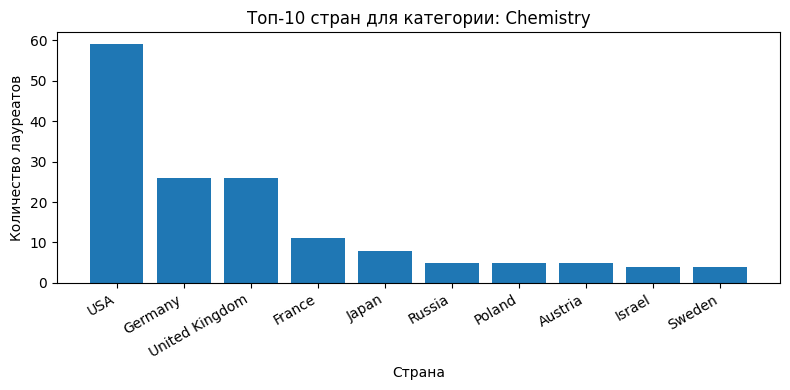

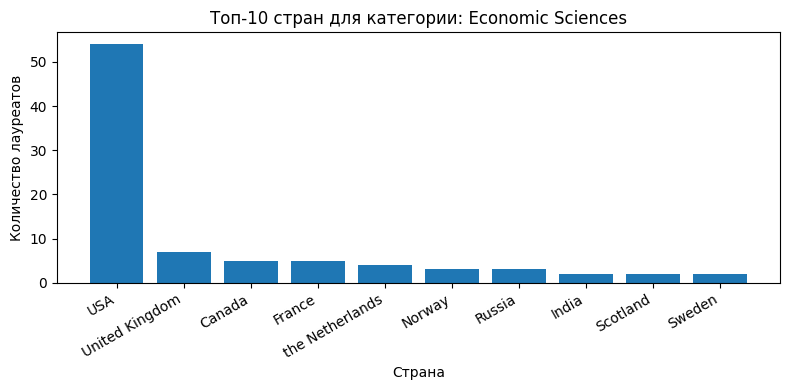

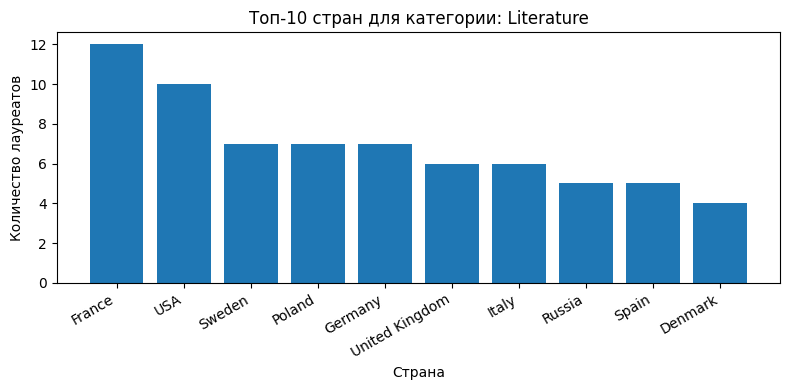

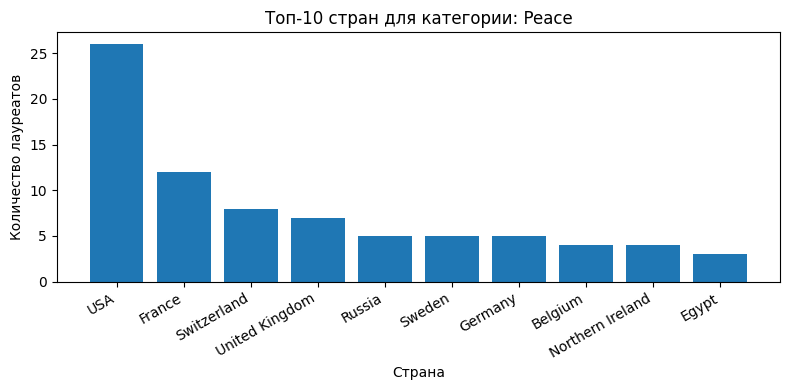

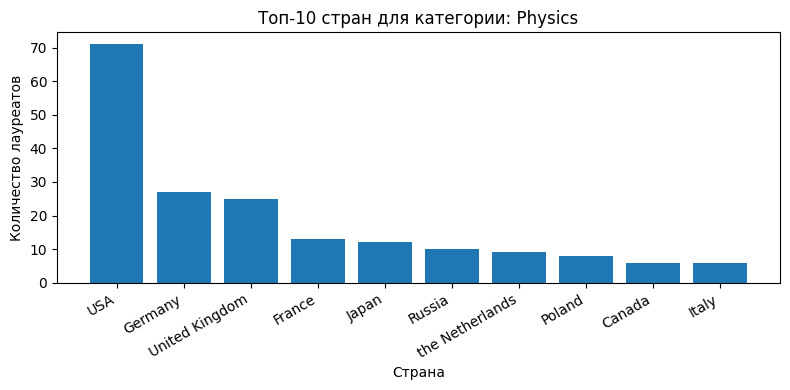

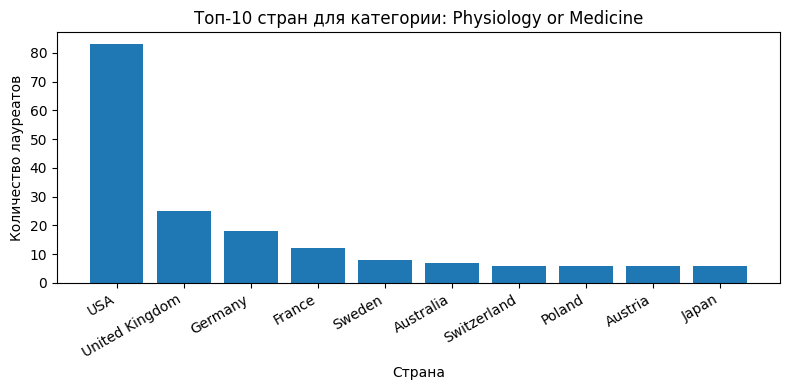

In [9]:
plot_top_countries_by_category(laureates_data, n=10)


## Выводы по задаче 2.1

Посмотрим на распределения по странам в топ-5, топ-10.

Почти везде лидируют США, Англия.
Часто высокие места занимают европейские страны (Германия, Франция, Швеция, Россия).
Из Азии — только Япония.

Это может быть связано с тем, что у этих стран самые развитые экономики, а значит, они выделяют больше денег на данные сферы и получают лучшие результаты. Также работает накопительный эффект: в лучших научных институтах получаются обычно лучшие результаты, а значит, туда едут все перспективные учёные и так далее.

По построенным графикам количества лауреатов топ-10 стран по категориям видно, что в естественных науках доминируют США, Англия.
В Германии химия держит хорошие позиции.

Премия мира и премия по литературе распределены равномернее. Это связано с тем, что эти области не такие требовательные к ресурсам и капиталу, и в них лучшими может стать потенциально больше стран.

## Задача 2.2 Возраст при награждении

Будем исследовать:

1. Средний и медианный возраст лауреатов на момент получения первого приза.

2. Исследовать, как средний возраст получения первого приза различается по категориям. Какие выводы можно из этого сделать?

3. Различаются ли средний и медианный возрасты?

Сначала посчитаем средние, медианы, количество записей для каждой категории.

In [10]:
import statistics

def is_person_record(rec):
    """
    Проверяем, что запись - человек.
    Принимает запись
    Возвращает True - человек /False - нет
    """
    return rec is not None and rec.get("type_") == "person"


def get_age_at_first_prize(person):
    """
    Для одного лауреата-человека считает возраст на момент первого приза.
    Возвращает кортеж (age, category_of_first_prize) или None, если посчитать нельзя.
    """
    if not is_person_record(person):
        return None

    birth_year = person.get("birth_year")
    prizes = person.get("prizes_relevant") or []

    if birth_year is None or not prizes:
        return None

    # находим приз с минимальным годом
    first_prize = None
    for p in prizes:
        aw = p.get("award_year")
        if aw is None:
            continue
        if first_prize is None or aw < first_prize.get("award_year"):
            first_prize = p

    if first_prize is None:
        return None

    award_year = first_prize.get("award_year")
    if award_year is None:
        return None

    age = award_year - birth_year
    if age < 0:
        return None

    category = first_prize.get("category_en")
    return age, category


def collect_ages_at_first_prize(laureates_data):
    """
    Собирает список возрастов (и категорий) для всех людей,
    у кого можно посчитать возраст на момент первого приза.
    Получает датасет на вход.
    Возвращает список словарей вида:
      {"id": ..., "name": ..., "age": ..., "category": ...}
    """
    out = []
    for rec in laureates_data:
        if not is_person_record(rec):
            continue
        res = get_age_at_first_prize(rec)
        if res is None:
            continue
        age, cat = res
        out.append({
            "id": rec.get("id"),
            "name": rec.get("name"),
            "age": age,
            "category": cat,
        })
    return out


def compute_mean_median(values):
    """
    функция считает среднее и медиану по списку чисел.
    Волучает на вход массив значений.
    Возвращает словарь {"mean": ..., "median": ..., "n": ...}
    Если список пустой — вернет None.
    """
    if not values:
        return {"mean": None, "median": None, "n": 0}
    return {
        "mean": statistics.mean(values),
        "median": statistics.median(values),
        "n": len(values),
    }


def overall_age_stats(laureates_data):
    """
    Средний и медианный возраст получения первого приза по всем людям.
    Получает исходный датасет
    Возврщает средний и медианный возраст, число записей.
    """
    rows = collect_ages_at_first_prize(laureates_data)
    ages = [r["age"] for r in rows]
    return compute_mean_median(ages)


def mean_median_age_by_category(laureates_data):
    """
    Считает средний возраст получения первого приза по категориям.
    Получает датасет исходный.
    Алгоритм: у каждого человека берём его первый приз, берём его категорию,
    группируем по категории и считаем mean/median внутри.
    Возвращает словарь:
    {
      "Physics": {"mean": ..., "median": ..., "n": ...},
      "Chemistry": {...},
      ...
    }
    """
    rows = collect_ages_at_first_prize(laureates_data)
    # сгруппируем по category
    groups = {}
    for r in rows:
        cat = r["category"]
        if cat is None:
            continue
        groups.setdefault(cat, []).append(r["age"])

    stats_by_cat = {}
    for cat, ages in groups.items():
        stats_by_cat[cat] = compute_mean_median(ages)
    return stats_by_cat


Выводим общие характеристики и по категориям

In [11]:
# 1. общий средний/медианный возраст
overall_stats = overall_age_stats(laureates_data)
print("Общий средний возраст:", round(overall_stats["mean"], 2))
print("Общий медианный возраст:", round(overall_stats["median"], 2))
print("Всего людей учли:", overall_stats["n"])

# 2. по категориям
by_cat = mean_median_age_by_category(laureates_data)
print("\nВозраст по категориям (первый приз):")
for cat, st in by_cat.items():
    print(
        cat,
        "mean=", round(st["mean"], 2),
        "median=", round(st["median"], 2),
        "n=", st["n"],
    )


Общий средний возраст: 60.44
Общий медианный возраст: 61.0
Всего людей учли: 990

Возраст по категориям (первый приз):
Economic Sciences mean= 67.01 median= 67 n= 99
Physics mean= 57.69 median= 56 n= 229
Chemistry mean= 59.16 median= 58 n= 197
Literature mean= 64.95 median= 67.0 n= 122
Peace mean= 60.76 median= 62 n= 111
Physiology or Medicine mean= 58.92 median= 58.0 n= 232


## Построим теперь графики для среднего и медианы по категориям.
## А также график разницы между средним и медианой по категориям.

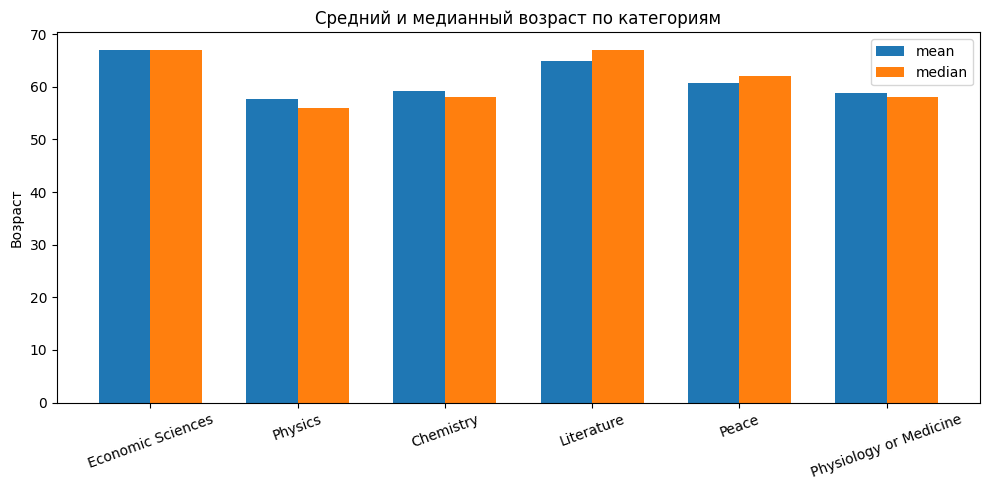

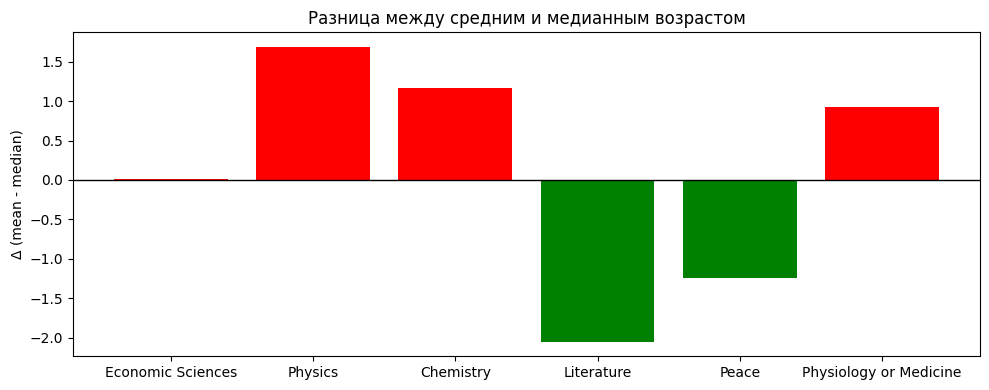

In [12]:
import matplotlib.pyplot as plt
stats_by_cat = mean_median_age_by_category(laureates_data)

categories = list(stats_by_cat.keys())
means = [stats_by_cat[c]["mean"] for c in categories]
medians = [stats_by_cat[c]["median"] for c in categories]
deltas = [means[i] - medians[i] for i in range(len(categories))]

x = range(len(categories))

# 1. Строим столбцы со средним и медианой
plt.figure(figsize=(10, 5))
bar_width = 0.35
plt.bar([i - bar_width/2 for i in x], means, width=bar_width, label="mean")
plt.bar([i + bar_width/2 for i in x], medians, width=bar_width, label="median")
plt.xticks(x, categories, rotation=20)
plt.ylabel("Возраст")
plt.title("Средний и медианный возраст по категориям")
plt.legend()
plt.tight_layout()
plt.show()

# 2. Строим дельту (mean - median) по категориям
plt.figure(figsize=(10, 4))
colors = []
for d in deltas:
    if d > 0:
        colors.append("red")
    elif d < 0:
        colors.append("green")
    else:
        colors.append("gray")

plt.bar(categories, deltas, color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Δ (mean - median)")
plt.title("Разница между средним и медианным возрастом")
plt.tight_layout()
plt.show()


## Построим распределние количества лауреатов по категориям в зависимости от возраста

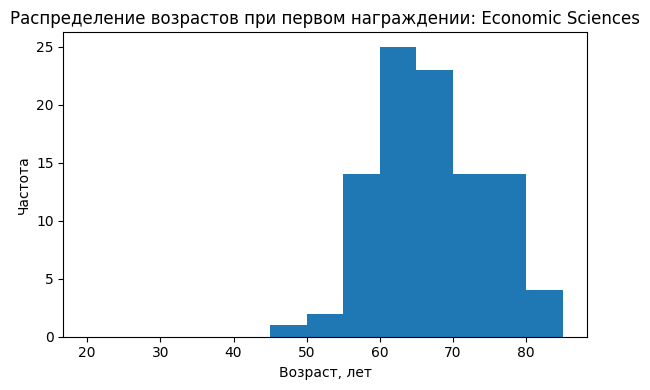

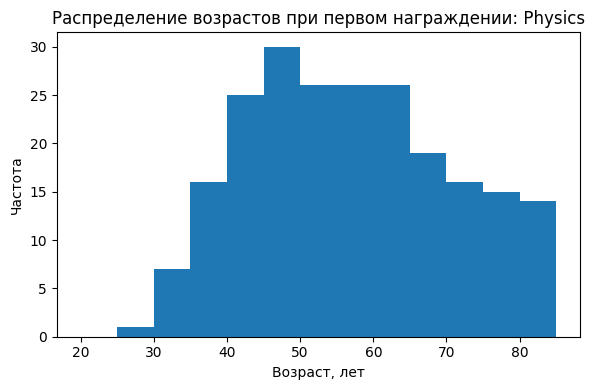

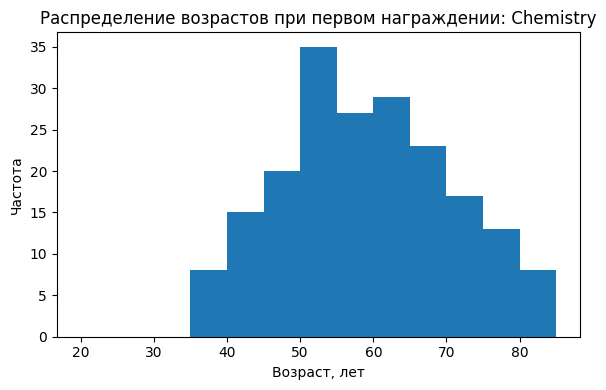

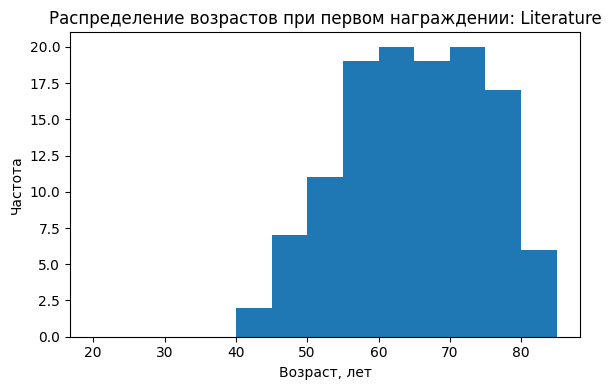

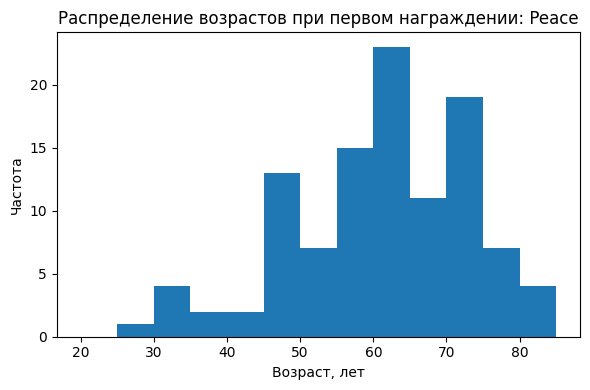

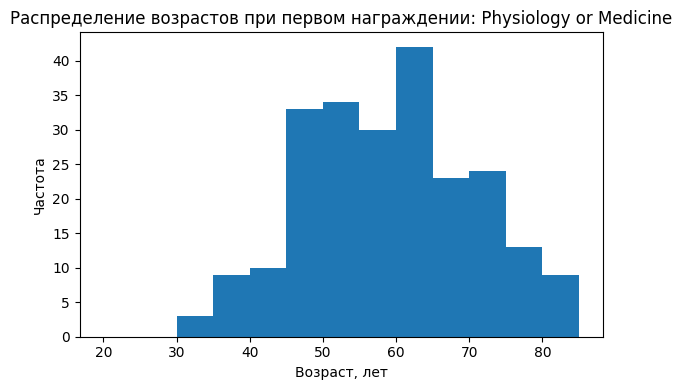

In [13]:
import matplotlib.pyplot as plt

def get_age_at_first_prize_full(person):
    """
    Возвращает (age, category, award_year) для человека,
    или None, если что-то посчитать нельзя.
    """
    if person is None or person.get("type_") != "person":
        return None

    birth_year = person.get("birth_year")
    prizes = person.get("prizes_relevant") or []
    if birth_year is None or not prizes:
        return None

    first = None
    for p in prizes:
        ay = p.get("award_year")
        if ay is None:
            continue
        if first is None or ay < first.get("award_year"):
            first = p

    if first is None:
        return None

    award_year = first.get("award_year")
    if award_year is None:
        return None

    age = award_year - birth_year
    if age < 0:
        return None

    category = first.get("category_en")
    return age, category, award_year


def get_ages_by_category(laureates_data):
    """
    Собирает ages = {category: [age1, age2, ...]}
    только для людей.
    """
    ages_by_cat = {}
    for rec in laureates_data:
        res = get_age_at_first_prize_full(rec)
        if res is None:
            continue
        age, category, _ = res
        if category is None:
            continue
        ages_by_cat.setdefault(category, []).append(age)
    return ages_by_cat


# выводим графики распределния количества по категориям в зависимости от возраста
ages_by_cat = get_ages_by_category(laureates_data)
bins = list(range(20, 90, 5))

for cat, ages in ages_by_cat.items():
    if not ages:
        continue
    plt.figure(figsize=(6, 4))
    plt.hist(ages, bins=bins)
    plt.title(f"Распределение возрастов при первом награждении: {cat}")
    plt.xlabel("Возраст, лет")
    plt.ylabel("Частота")
    plt.tight_layout()
    plt.show()


# Выводы по задаче 2.2
## Анализ общей сравнительной статистики по возрасту получения первой премии
В ходе анализа видно, что категории с минимальным возрастом лауреатов — это:
физика, химия, медицина.
(Physics mean = 57.69, median = 56, n = 229
Chemistry mean = 59.16, median = 58, n = 197
Physiology or Medicine mean = 58.92, median = 58.0, n = 232)

Это может быть связано с тем, что мозг лучше всего работает до определённого возраста, и открытия в таких сложных с точки зрения понимания различных концепций науках делают более молодые люди.

Самые «взрослые» же награды — по экономическим наукам, литературе, а также премия мира.
Economic Sciences mean = 67.01, median = 67, n = 99
Literature mean = 64.95, median = 67.0, n = 122
Peace mean = 60.76, median = 62, n = 111
Physiology or Medicine mean = 58.92, median = 58.0, n = 232

Это можно объяснить тем, что в этих сферах важнее жизненный опыт и объём накопленных знаний, благодаря которым человек может создать литературное произведение или новую философскую концепцию.

Разница между средним и медианой может свидетельствовать о том, что в естественных науках иногда награждают людей сильно старше среднего возраста, учёных маститых, в возрасте, может быть, с задержкой по их проведённым исследованиям — это сдвигает среднее вправо.

А в литературе, премии мира среднее смещено, наоборот, в сторону более молодого возраста, так как в целом иногда и очень молодые могут создать что-то значимое в этих сферах, а одобрение от сообщества можно получить быстрее. Также эти области могут быть немного проще для получения премии, что позволяет стать лауреатами очень молодым.

Разница между средним и медианой может свидетельствовать о том, что в естественных науках иногда награждают людей сильно старше среднего возраста, ученых маститых в возрасте, может с задрежкой по их проведенным исследованиям, это сдвигает среднее вправо.

А в Литературе, премии мира среднее смещено, наоборот, в сторону молодого возраста, так как в целом иногда и очень молодые могут создать что-то значимое в этих сферах, а одобрение от сообщества можно получить быстрее часто. Также данные науки могут быть немного проще для получения премии, что позволяет стать лауреатами очень молодым.

## Анализ характера распределений количества лауреатов премии от возраста, когда они получили свою первую награду

Схожим с нормальным распределением обладают: химия, медицина, экономические науки.

В премии мира виден сильный разброс значений, что связано с тем, что премию может получить любой политический активист независимо от возраста, признать лауреатом могут достаточно быстро.

В физике наблюдается высокий «хвост» распределения в области больше медианного значения, что свидетельствует о сложности области и о том, что научные работы могут быть признаны через долгое время.

В премии по литературе наблюдается резкий подъём к возрасту 55 лет и примерно равный участок (плато) количества лауреатов с 55 до 80 лет.
Необходимо время, чтобы написать работы, стать известным, получить одобрение от сообщества. А сделать все эти действия можно равновероятно в зрелом возрасте, плюс дельта на одобрение — поэтому и получается под конец жизни, с равной вероятностью.

Посмотрим на распределения по странам в топ-5, топ-10.

Почти везде лидируют США, Англия.
Часто высокие места занимают европейские страны (Германия, Франция, Швеция, Россия).
Из Азии — только Япония.

Это может быть связано с тем, что у этих стран самые развитые экономики, а значит, они выделяют больше денег на данные сферы и получают лучшие результаты. Также работает накопительный эффект: в лучших научных институтах получаются обычно лучшие результаты, а значит, туда едут все перспективные учёные и так далее.

По построенным графикам количества лауреатов топ-10 стран по категориям видно, что в естественных науках доминируют США, Англия.
Но в химии Германия ещё держит хорошие позиции.

Премия мира и премия по литературе распределены равномернее. Это связано с тем, что эти области не такие требовательные к ресурсам и капиталу, и в них лучшими может стать потенциально больше стран.

----------